# 실습 

### 통신회사의 고객 이탈 여부를 logistic regression 으로 예측

In [1]:
# 필요한 라이브러리 import
import pandas as pd  # 데이터프레임 처리를 위한 라이브러리
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀 모델
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score  # 분류 모델 평가 지표

# CSV 파일에서 고객 이탈 데이터 읽어오기
churn_df = pd.read_csv("datasets/ChurnData.csv")

## Data pre-processing and feature selection

개별 feature 에 대한 분석 후(본 과정에서는 생략)에 Logistic Regression 에 사용할 feature 선정

tenure(가입기간), age (연령), income(수입) 으로 예측하고 churn (이탈여부) 은 integer 로 type 변경

In [2]:
# 데이터프레임의 처음 5개 행 확인 (데이터 구조 파악)
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [3]:
# 특성 선택: 로지스틱 회귀에 사용할 특성만 선택
# tenure: 가입기간, age: 연령, income: 수입, churn: 이탈여부
churn_df = churn_df[['tenure', 'age', 'income', 'churn']]
# 선택된 특성 확인
churn_df.head()

,tenure,age,income,churn
0,11.0,33.0,136.0,1.0
1,33.0,33.0,33.0,1.0
2,23.0,30.0,30.0,0.0
3,38.0,35.0,76.0,0.0
4,7.0,35.0,80.0,0.0


In [4]:
# 입력 특성 X와 타깃 변수 y 분리
# X: 예측에 사용할 특성 (가입기간, 연령, 수입)
X = churn_df[['tenure', 'age', 'income']]
# y: 예측하고자 하는 타깃 변수 (이탈여부: 0=유지, 1=이탈)
y = churn_df['churn']

### Train/Test dataset 분리

In [5]:
from sklearn.model_selection import train_test_split

# 데이터를 학습용과 테스트용으로 분할
# test_size=0.2: 전체 데이터의 20%를 테스트 데이터로 사용 (80% 학습, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### data scaling

In [6]:
from sklearn.preprocessing import StandardScaler

# 데이터 표준화 (평균 0, 표준편차 1로 스케일링)
# StandardScaler: Z-score 정규화 (로지스틱 회귀에서 특성 간 스케일 차이를 줄이기 위해 필요)
sc = StandardScaler()

# 학습 데이터에 대해 평균과 표준편차를 계산하고 변환
X_train = sc.fit_transform(X_train)

# 테스트 데이터는 학습 데이터의 기준으로만 변환 (데이터 누수 방지)
X_test = sc.transform(X_test)

In [7]:
# 로지스틱 회귀 모델 객체 생성
clf = LogisticRegression()

# 모델 학습
# values.ravel(): pandas Series를 1차원 배열로 변환 (sklearn이 요구하는 형식)
clf.fit(X_train, y_train.values.ravel())

# 테스트 데이터에 대해 예측 수행
y_pred = clf.predict(X_test)

In [8]:
# 혼동 행렬(Confusion Matrix) 계산
# labels=[1,0]: 행과 열의 순서를 [이탈, 유지]로 지정
# 혼동 행렬 구조:
#           예측
#        이탈  유지
# 실제 이탈 [TP  FN]
#     유지 [FP  TN]
cm = confusion_matrix(y_test, y_pred, labels=[1,0])
print("혼동 행렬 (Confusion Matrix):\n", cm)
print()

# F1 Score 계산: Precision과 Recall의 조화평균
# F1 = 2 * (Precision * Recall) / (Precision + Recall)
f1 = f1_score(y_test, y_pred, labels=[1,0])
print(f"F1 Score: {f1:.2f}")
print()

# 정확도(Accuracy): 전체 예측 중 올바르게 예측한 비율
# Accuracy = (TP + TN) / (TP + TN + FP + FN)
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 (Accuracy): {accuracy:.2f}")

# 정밀도(Precision): 이탈로 예측한 것 중 실제로 이탈한 비율
# Precision = TP / (TP + FP)
precision = precision_score(y_test, y_pred)
print(f"정밀도 (Precision): {precision:.2f}")

# 재현율(Recall): 실제 이탈한 고객 중 올바르게 예측한 비율
# Recall = TP / (TP + FN)
recall = recall_score(y_test, y_pred)
print(f"재현율 (Recall): {recall:.2f}")

혼동 행렬 (Confusion Matrix):
 [[ 1  6]
 [ 6 27]]

F1 Score: 0.14

정확도 (Accuracy): 0.70
정밀도 (Precision): 0.14
재현율 (Recall): 0.14


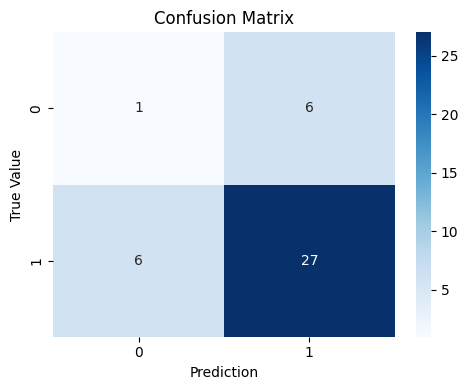

In [9]:
import seaborn as sns  # 통계 데이터 시각화 라이브러리
import matplotlib.pyplot as plt  # 그래프 시각화 라이브러리

# 혼동 행렬 시각화
plt.figure(figsize=(5, 4))

# 히트맵으로 혼동 행렬 표시
# annot=True: 각 셀에 숫자 값 표시
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# 그래프 제목 및 축 라벨 설정
ax.set_title('Confusion Matrix')
ax.set_xlabel('Prediction')
ax.set_ylabel('True Value')

plt.tight_layout()
plt.show()